In [1]:
import os
import re
from functools import reduce
from typing import Any

import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from nltk.corpus import wordnet as wn
from nltk.tokenize import RegexpTokenizer
from sklearn.preprocessing import LabelEncoder

# MISC_DATA_PATH = os.path.join(os.path.pardir, "MISC")
MISC_DATA_PATH = os.path.join(os.path.pardir, os.path.pardir, "MISC")
# MISC_DATA_PATH = os.path.join(os.path.curdir, "drive/MyDrive/COMP6713/MISC")
JOB_DATA_PATH = os.path.join(MISC_DATA_PATH, "job_data_files")

print(MISC_DATA_PATH)
print(JOB_DATA_PATH)

..\..\MISC
..\..\MISC\job_data_files


In [ ]:
work_arrangements_development_set_path = os.path.join(JOB_DATA_PATH, "work_arrangements_development_set.csv")
work_arrangements_test_set_path = os.path.join(JOB_DATA_PATH, "work_arrangements_test_set.csv")

df_dev = pd.read_csv(work_arrangements_development_set_path)
df_test = pd.read_csv(work_arrangements_test_set_path)

df_dev.head()

,id,job_ad,y_true
0,79484040,Job title: CEO\nAbstract: Exciting opportunity...,Remote
1,80331384,Job title: Home-Based Online ESL Teacher (Onli...,Remote
2,79721069,"Job title: Safeguarding, De La Salle\nAbstract...",Hybrid
3,80190376,Job title: Delivery Driver\nAbstract: Pickup t...,OnSite
4,80082230,Job title: Store Supervisor\nAbstract: We are ...,OnSite


In [ ]:
class Preprocessing:
    def __init__(self, df: pd.DataFrame):
        self.df = df  # type: pd.DataFrame
        self.id = df["id"].tolist()  # type: list[int]

        self.y_true = [x.lower() for x in df["y_true"].tolist()]  # type: list[str]

        self.job_ads = []  # type: list[list[str]]
        job_ads_str_list = [x.split("\n") for x in df["job_ad"].tolist()]
        pattern = r"[A-Za-z]+(?:'[A-Za-z]+)*"
        tokenizer = RegexpTokenizer(pattern, flags=re.UNICODE)
        for job_ad, y in zip(job_ads_str_list, self.y_true):
            job_ad = [x for x in job_ad if x]
            job_ad = list(map(lambda x: x.lower(), job_ad))
            job_ad = [re.sub(r"http?\:?\S+", "", x) for x in job_ad]
            job_ad = [re.sub(r"www\.\S+", "", x) for x in job_ad]
            job_ad = [tokenizer.tokenize(x) for x in job_ad]
            job_ad = reduce(lambda x, y: x + y, job_ad)
            job_ad.append(y)
            self.job_ads.append(job_ad)

    def get_pair(self, index: int) -> tuple[list[str], str]:
        return self.job_ads[index], self.y_true[index]


pre_dev = Preprocessing(df_dev)
pre_test = Preprocessing(df_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier


def get_sentence_vector_by_glove(
    sentence: list[str], glove_model: dict[str, np.ndarray]
) -> np.ndarray:
    vectors = [glove_model[word] for word in sentence if word in glove_model]
    if not vectors:
        return np.zeros(len(glove_model[next(iter(glove_model))]))
    return np.mean(vectors, axis=0)


def load_glove_model(glove_file: str) -> dict[str, np.ndarray]:
    embeddings = {}
    with open(glove_file, "r", encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector
    return embeddings


class WA_Model:
    def __init__(self, sentences: list[list[str]], method: Any) -> None:
        """Initialize the model."""
        self.model = None  # type: Any
        self.label_encoder = LabelEncoder()
        self.method = method  # type: Any
        self.nfeatures = 0  # type: int
        if method == "glove":
            self.nfeatures = 50
        elif method == "word2vec":
            self.nfeatures = 1000
        else:
            raise ValueError("Method must be 'word2vec' or 'glove'")

        self.word2vec_model = Word2Vec(
            sentences=sentences,
            vector_size=self.nfeatures,
            window=5,
            min_count=1,
            workers=4,
        )
        glove_model_path = os.path.join(MISC_DATA_PATH, "glove.6B.50d.txt")
        print(f"Loading glove model from {glove_model_path}")
        self.glove_model = load_glove_model(glove_model_path)

    def get_word_vector(self, word: str) -> np.ndarray:
        if word in self.word2vec_model.wv:
            return self.word2vec_model.wv[word]
        else:
            return np.random.uniform(
                -0.1, 0.1, self.word2vec_model.vector_size
            )  # OOV words

    def get_sentence_vector_by_word2vec(self, sentence: list[str]) -> np.ndarray:
        if not self.word2vec_model:
            raise ValueError("Word2Vec model not initialized")
        vectors = [
            self.get_word_vector(word)
            for word in sentence
            if word in self.word2vec_model.wv
        ]
        return (
            np.mean(vectors, axis=0)
            if vectors
            else np.zeros(self.word2vec_model.vector_size)
        )

    def use_word2vec(self, X_list: list[list[str]]) -> np.ndarray:
        return np.array([self.get_sentence_vector_by_word2vec(sent) for sent in X_list])

    def use_glove(self, X_list: list[list[str]]) -> np.ndarray:
        return np.array(
            [get_sentence_vector_by_glove(sent, self.glove_model) for sent in X_list]
        )

    def fit(self, X: list[list[str]], y: list[str]) -> None:
        X_train = self.use_word2vec(X)
        # X_train = self.use_glove(X)
        y_train = self.label_encoder.fit_transform(y)
        self.model.fit(X_train, y_train)

    def predict(self, X: list[list[str]]) -> list[str]:
        X_pred = self.use_word2vec(X)
        y_pred = self.model.predict(X_pred)
        y_pred = self.label_encoder.inverse_transform(y_pred)
        return y_pred.tolist()

In [ ]:
wa = WA_Model(pre_dev.job_ads, method="word2vec")
# RandomForestClassifier
wa.model = RandomForestClassifier(n_estimators=1000, max_depth=30, random_state=42)
# Support Vector Classifier
# wa.model = SVC(kernel="sigmoid", C=1.0, gamma="scale", random_state=42)
wa.fit(pre_dev.job_ads, pre_dev.y_true)
y_pred = wa.predict(pre_test.job_ads)

print(f"y_pred: {y_pred}")

Loading glove model from ..\..\MISC\glove.6B.50d.txt
y_pred: ['onsite', 'onsite', 'hybrid', 'hybrid', 'remote', 'hybrid', 'onsite', 'hybrid', 'hybrid', 'hybrid', 'remote', 'onsite', 'remote', 'hybrid', 'onsite', 'hybrid', 'hybrid', 'onsite', 'hybrid', 'onsite', 'onsite', 'onsite', 'onsite', 'onsite', 'onsite', 'onsite', 'remote', 'onsite', 'remote', 'onsite', 'onsite', 'hybrid', 'hybrid', 'remote', 'onsite', 'hybrid', 'onsite', 'onsite', 'onsite', 'onsite', 'onsite', 'onsite', 'hybrid', 'onsite', 'hybrid', 'remote', 'hybrid', 'onsite', 'onsite', 'hybrid', 'onsite', 'hybrid', 'onsite', 'onsite', 'hybrid', 'hybrid', 'hybrid', 'hybrid', 'remote', 'remote', 'onsite', 'hybrid', 'onsite', 'onsite', 'onsite', 'remote', 'hybrid', 'onsite', 'onsite', 'onsite', 'hybrid', 'onsite', 'onsite', 'onsite', 'hybrid', 'onsite', 'hybrid', 'remote', 'onsite', 'onsite', 'onsite', 'hybrid', 'hybrid', 'onsite', 'onsite', 'hybrid', 'onsite', 'onsite', 'remote', 'onsite', 'onsite', 'remote', 'onsite', 'onsite'

y_test: ['onsite', 'onsite', 'remote', 'hybrid', 'remote', 'onsite', 'hybrid', 'remote', 'hybrid', 'remote', 'hybrid', 'onsite', 'remote', 'onsite', 'onsite', 'onsite', 'onsite', 'remote', 'onsite', 'remote', 'remote', 'hybrid', 'remote', 'hybrid', 'onsite', 'onsite', 'hybrid', 'onsite', 'remote', 'onsite', 'onsite', 'hybrid', 'hybrid', 'remote', 'onsite', 'onsite', 'onsite', 'hybrid', 'hybrid', 'onsite', 'hybrid', 'remote', 'remote', 'remote', 'hybrid', 'onsite', 'onsite', 'remote', 'remote', 'onsite', 'hybrid', 'hybrid', 'onsite', 'onsite', 'onsite', 'remote', 'onsite', 'hybrid', 'hybrid', 'remote', 'onsite', 'hybrid', 'onsite', 'hybrid', 'remote', 'remote', 'remote', 'hybrid', 'onsite', 'onsite', 'hybrid', 'onsite', 'onsite', 'hybrid', 'onsite', 'remote', 'onsite', 'remote', 'onsite', 'onsite', 'hybrid', 'onsite', 'hybrid', 'onsite', 'remote', 'hybrid', 'onsite', 'onsite', 'onsite', 'hybrid', 'remote', 'onsite', 'onsite', 'remote', 'onsite', 'hybrid', 'onsite', 'onsite', 'onsite']
a

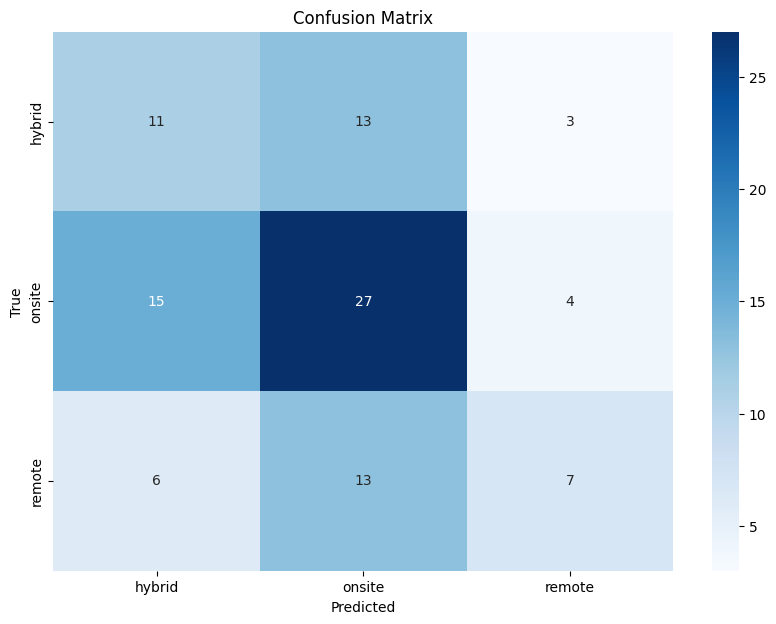

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"y_test: {pre_test.y_true}")
accuracy = accuracy_score(pre_test.y_true, y_pred)
print(f"accuracy: {accuracy}")
print(classification_report(pre_test.y_true, y_pred))

cm = confusion_matrix(pre_test.y_true, y_pred, labels=wa.label_encoder.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=wa.label_encoder.classes_, yticklabels=wa.label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()